In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
df = pd.read_csv("dataset/football_matches_dataset.csv")

In [3]:
clean_df = df.drop(columns=["Unnamed: 0"])

In [4]:
clean_df["datetime"] = pd.to_datetime(clean_df["datetime"])

In [5]:
conditions = [
    clean_df["home_score"] > clean_df["away_score"],
    clean_df["home_score"] < clean_df["away_score"]
]

choices = [
    "Home Win",
    "Away Win"
]

clean_df["match_result"] = np.select(
    conditions,
    choices,
    default="Draw"
)

#this step it could be done with a for loop (was my firts test actually), but choosing np.select() will improve speed and let me apply pandas.   BORRAR
# np.select(condlist, choicelist, default=...) variables as condition and chioces, are not reserved words for this np function, we could use a,b. 
# BUT Without specifying default, np.select() uses 0 as the default value. 

In [6]:
clean_df["goal_difference"] = clean_df["home_score"] - clean_df["away_score"]

### 3.7 recent_form_difference
sums up scores (goals) of last_4_matches

* Relevant variables:

- (not 15-16 - total number of points home/away team have gained in their previous 4 matches)
- 19-20 - total number of goals home/away team have scored in their previous 4 matches 
- 23-24 - total number of goals home/away team have conceded (goals against) in their previous 4 matches

(each) - can be NaN in case of the first matches of the season when teams have not played enough matches this season yet

In [7]:
# Speaking of Points - Form could be calculated as the sum of the last 4 matches points (a+h) 
#clean_df.home_points_last_4_matches
#clean_df.away_points_last_4_matches
newcol = clean_df.home_points_last_4_matches - clean_df.away_points_last_4_matches
clean_df["recent_form_difference"] = newcol

# Speaking of Scores - Form could be calculated as the sum of the last 4 matches scores: (a+h) 
# the result per game is goals_L4m - goals_againstL4m; sum(a+h)
#clean_df.away_goals_last_4_matches
#clean_df.away_goals_against_last_4_matches
#clean_df.home_goals_last_4_matches
#clean_df.home_goals_against_last_4_matches
newcola = clean_df.away_goals_last_4_matches - clean_df.away_goals_against_last_4_matches
newcolh = clean_df.home_goals_last_4_matches - clean_df.home_goals_against_last_4_matches

newcols = newcolh - newcola
newcols.shape
type(newcols)
#newcols.tail(10)
#clean_df["recent_form_difference"] = newcols

#print(clean_df["recent_form_difference"].tail(10))
clean_df["recent_form_difference"] = (
    clean_df["home_points_last_4_matches"]
    - clean_df["away_points_last_4_matches"]
)   

### Methodological Note

The original implementation explored two different ways of measuring recent form:

- Using the total points from the last 4 matches.
- Using the goal balance from the last 4 matches.

However, neither approach was completed as the final feature, and both calculations combined the values from the home and away teams instead of comparing them.

Since our Research Question is:

> **Does recent team form influence match outcomes?**

we need to compare the recent form of both teams before the match.

For this reason, we calculate:

```python
clean_df["recent_form_difference"] = (
    clean_df["home_points_last_4_matches"]
    - clean_df["away_points_last_4_matches"]
)
```

This feature is easier to interpret:

- Positive values → Home team was in better recent form.
- Negative values → Away team was in better recent form.
- Values close to zero → Both teams had similar recent form.

This implementation better matches the objective of Research Question 2.

2. Does recent team performance influence match outcomes?

Why? The dataset contains extensive information about recent team performance.

Main Variables: Previous Points, Previous Goals Scored, Previous Goals Conceded,
Previous xG, Match Result, League.

Possible Analysis: Team form, winning probability and performance trends.

In [34]:
[col for col in df.columns if "home" in col.lower()]

['home_team',
 'home_score',
 'home_xg',
 'home_standings',
 'home_points',
 'home_points_last_4_matches',
 'home_points_last_2_home_matches',
 'home_goals_last_4_matches',
 'home_goals_last_2_home_matches',
 'home_goals_against_last_4_matches',
 'home_goals_against_last_2_home_matches',
 'home_mean_xg_last_4_matches',
 'home_mean_xg_last_2_home_matches',
 'home_mean_xg_against_last_4_matches',
 'home_mean_xg_against_last_2_home_matches',
 'home_formation',
 'home_defense_rating',
 'home_midfield_rating',
 'home_attack_rating',
 'home_defense_rating_last_4_matches',
 'home_defense_rating_last_2_home_matches',
 'home_midfield_rating_last_4_matches',
 'home_midfield_rating_last_2_home_matches',
 'home_attack_rating_last_4_matches',
 'home_attack_rating_last_2_home_matches']

In [8]:
ctform = pd.crosstab(clean_df["recent_form_difference"], clean_df["match_result"], margins=True, margins_name="Total")
ctform


match_result,Away Win,Draw,Home Win,Total
recent_form_difference,,,,
-12.0,14,2,4,20
-11.0,26,10,3,39
-10.0,33,20,17,70
-9.0,93,37,30,160
-8.0,151,69,78,298
-7.0,168,88,106,362
-6.0,280,157,188,625
-5.0,344,234,270,848
-4.0,376,237,316,929


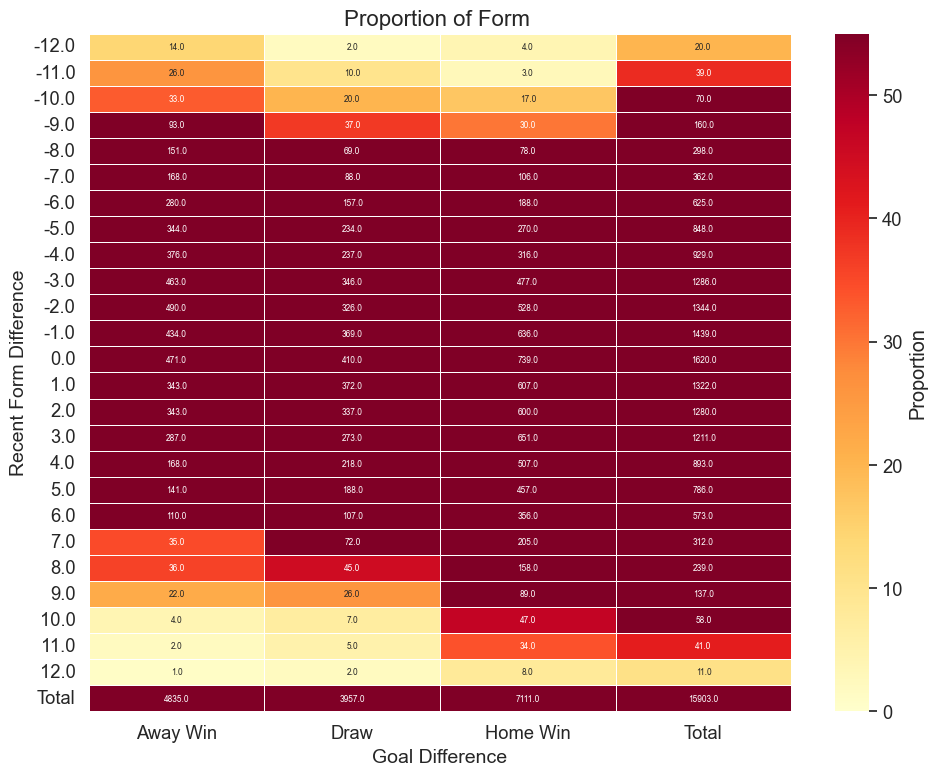

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Größere Leinwand (Breite, Höhe in Zoll)
plt.figure(figsize=(10, 8))

# 2. (Optional) Alle Schriften im Plot um 20% vergrößern
sns.set(font_scale=1.2)

sns.heatmap(
    ctform,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0, vmax=55,
    cbar_kws={'label': 'Proportion'},
    annot_kws={'size': 6}  
)

plt.title('Proportion of Form ', fontsize=16)
plt.xlabel('Goal Difference', fontsize=14)
plt.ylabel('Recent Form Difference', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
clean_df.groupby("match_result")["recent_form_difference"].mean()

match_result
Away Win   -1.443640
Draw       -0.350771
Home Win    0.829279
Name: recent_form_difference, dtype: float64

In [17]:
spearman_corr = clean_df['goal_difference'].corr(clean_df['recent_form_difference'], method='spearman')
print(f"Spearman-correlation Result to Form: {spearman_corr:.3f}")
# the robust one

Spearman-correlation Result to Form: 0.258


In [60]:
pearson_corr = clean_df['goal_difference'].corr(clean_df['recent_form_difference'])
print(f"Pearson-correlation Result to Form: {pearson_corr:.3f}")
# for linear correlation

Pearson-correlation Result to Form: 0.269


Correlation of goal_difference (the match result) to recent form (difference) is weak, just below medium correlated. 

Text(0, 0.5, 'Ø Recent Form Difference')

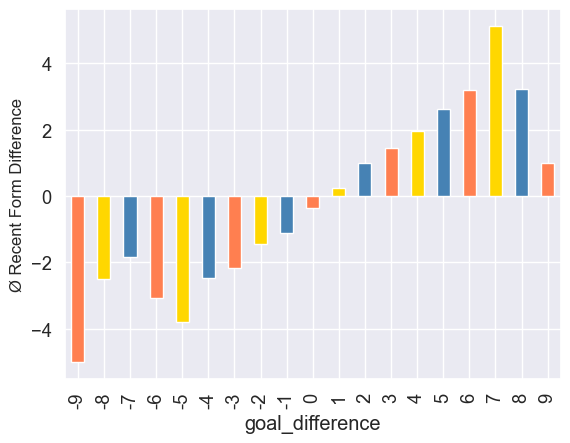

In [68]:
clean_df.groupby("goal_difference")["recent_form_difference"].mean().plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')
plt.ylabel('Ø Recent Form Difference', fontsize=12)

In [74]:
tempdf = clean_df
tempdf['goals_difference_home'] = clean_df['home_goals_last_4_matches'] - clean_df['home_goals_against_last_4_matches']

Text(0, 0.5, 'Ø Recent Goals Difference')

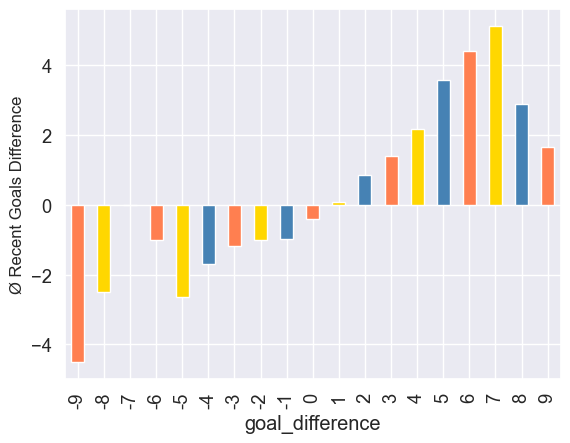

In [92]:
 #Previous Points, 
 #Previous Goals Scored, Previous Goals Conceded,
 #Previous xG, Match Result, League

tempdf.groupby("goal_difference")["goals_difference_home"].mean().plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')
plt.ylabel('Ø Recent Goals Difference', fontsize=12)


Text(0, 0.5, 'Recent Home Goals')

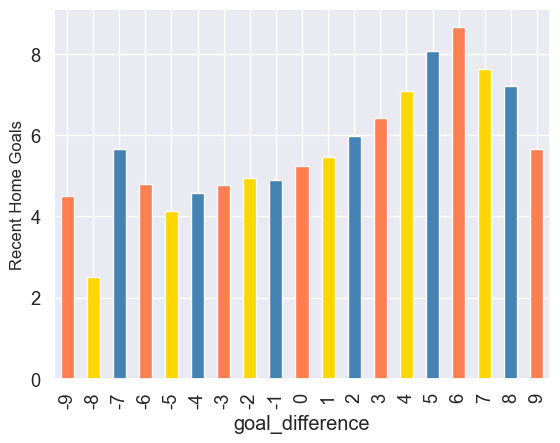

In [93]:
tempdf.groupby("goal_difference")["home_goals_last_4_matches"].mean().plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')
plt.ylabel('Recent Home Goals', fontsize=12)

In [94]:
spearman_corr = clean_df['goal_difference'].corr(clean_df['home_goals_last_4_matches'], method='spearman')
print(f"Spearman-correlation Result to home goals last 4 matches: {spearman_corr:.3f}")

Spearman-correlation Result to home goals last 4 matches: 0.181


Text(0, 0.5, 'Ø xG Difference')

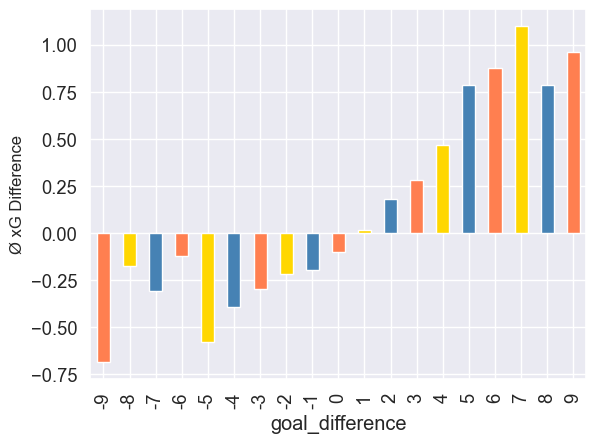

In [96]:

tempdf['xg_difference'] = clean_df['home_mean_xg_last_4_matches'] - clean_df['home_mean_xg_against_last_4_matches']
tempdf.groupby("goal_difference")["xg_difference"].mean().plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')
plt.ylabel('Ø xG Difference', fontsize=12)

In [83]:
df_matches_bl = clean_df[clean_df['league'] == 'Bundesliga']
df_matches_la = clean_df[clean_df['league'] == 'La liga']
df_matches_pl = clean_df[clean_df['league'] == 'EPL']
df_matches_sa = clean_df[clean_df['league'] == 'Serie A']
df_matches_l1 = clean_df[clean_df['league'] == 'Ligue 1']

clean_df['league'].unique()
print(df_matches_bl.shape, df_matches_la.shape, df_matches_pl.shape, df_matches_sa.shape, df_matches_l1.shape)

(2754, 59) (3420, 59) (3420, 59) (3420, 59) (3318, 59)


<Axes: xlabel='home_score'>

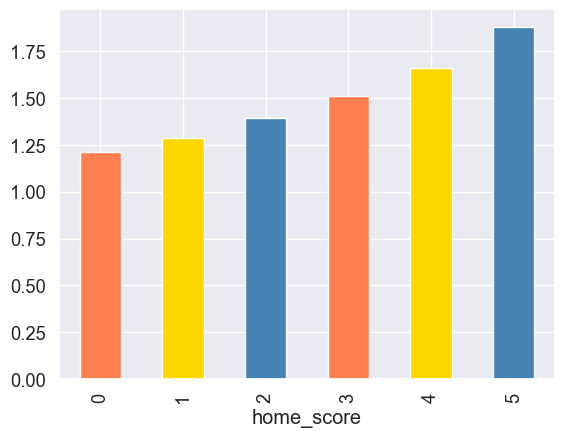

In [97]:
#tempdf.groupby("home_score")["home_goals_last_4_matches"].mean().plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')
filtered_df = tempdf[tempdf['home_score'] < 6]
#filtered_df.groupby("home_score")["home_goals_last_4_matches"].mean().plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')

filtered_df.groupby("home_score")["home_goals_last_4_matches"].mean().mul(0.25).plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')


In [105]:
filtered_df.groupby("home_score")["home_goals_last_4_matches"].sum()
pd.crosstab( filtered_df["home_goals_last_4_matches"], filtered_df["home_score"], margins=True, margins_name="Total")

home_score,0,1,2,3,4,5,Total
home_goals_last_4_matches,,,,,,,
0.0,39,60,18,15,6,0,138
1.0,184,237,146,45,16,1,629
2.0,403,482,314,126,43,14,1382
3.0,547,737,504,209,67,20,2084
4.0,631,837,579,277,95,36,2455
5.0,565,823,548,291,119,28,2374
6.0,438,635,521,237,99,39,1969
7.0,322,494,379,219,79,34,1527
8.0,221,339,306,170,60,33,1129


C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_18964\419438011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["home_goals_last_4_matches_avg"] = filtered_df["home_goals_last_4_matches"].mul(0.25)


<Axes: ylabel='Frequency'>

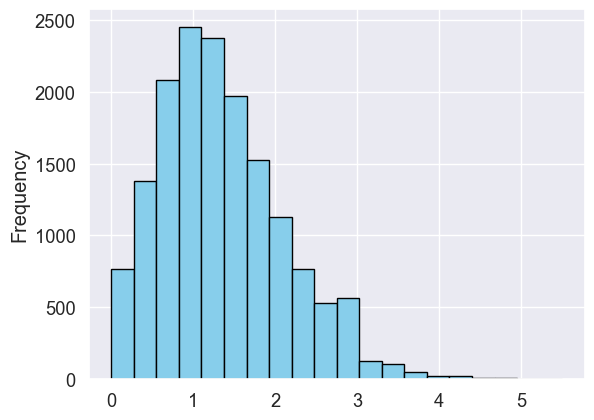

In [111]:
filtered_df["home_goals_last_4_matches"].describe()
filtered_df["home_goals_last_4_matches_avg"] = filtered_df["home_goals_last_4_matches"].mul(0.25)

filtered_df["home_goals_last_4_matches_avg"].describe()

filtered_df["home_goals_last_4_matches_avg"].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')

In [115]:
filtered_df.home_score.sum() / filtered_df.shape[0]

np.float64(1.4914698973915193)

In [118]:
filtered_df['rank_diff'] = filtered_df.home_standings - filtered_df.away_standings


C:\Users\M. Grillo\AppData\Local\Temp\ipykernel_18964\1018216561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['rank_diff'] = filtered_df.home_standings - filtered_df.away_standings


<Axes: xlabel='goal_difference'>

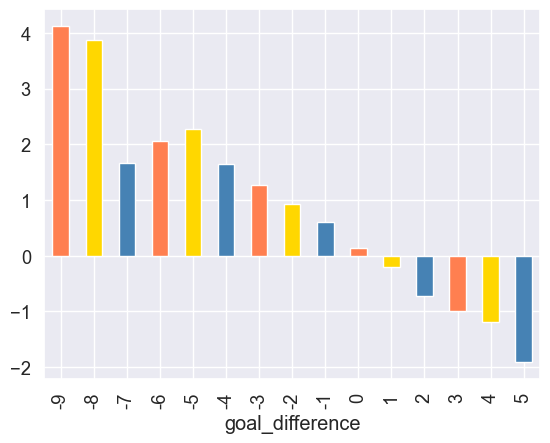

In [119]:
filtered_df.groupby("goal_difference")["rank_diff"].mean().mul(0.25).plot(kind='bar',  color=['coral', 'gold', 'steelblue'], edgecolor='white')

In [122]:
crosstab = pd.crosstab(filtered_df['goal_difference'], filtered_df['rank_diff'], margins=True, margins_name="Total").T
crosstab

goal_difference,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,Total
rank_diff,,,,,,,,,,,,,,,,
-19,0,0,0,0,0,0,0,0,0,1,1,4,5,1,3,15
-18,0,0,0,0,0,0,0,0,5,7,13,10,7,8,7,57
-17,0,0,0,0,0,0,0,2,3,13,22,22,12,7,6,87
-16,0,0,0,0,0,0,1,0,3,14,30,32,21,12,2,115
-15,0,0,0,0,0,0,2,3,8,27,42,40,25,13,9,169
-14,0,0,0,0,0,0,2,4,12,41,54,53,32,12,5,215
-13,0,0,0,0,0,0,0,8,24,48,58,56,48,14,8,264
-12,0,0,0,0,0,1,4,7,24,71,65,79,35,17,2,305
-11,0,0,0,0,0,0,3,19,44,80,71,48,45,17,6,333


<Axes: xlabel='goal_difference'>

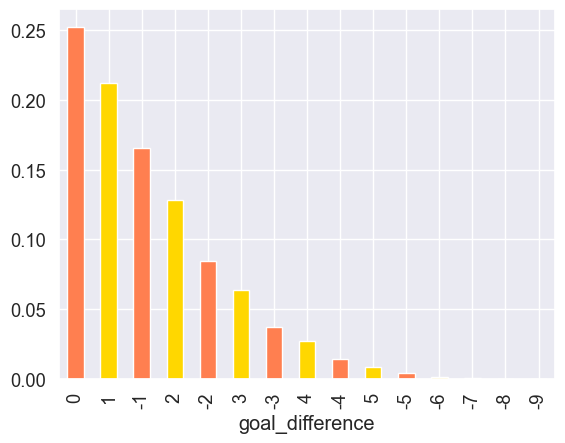

In [150]:
filtered_df['goal_difference'].value_counts(normalize=True).plot(kind='bar', color=['coral', 'gold'], edgecolor='white')

In [149]:
filtered_df['goal_difference'].value_counts()

goal_difference
 0    4087
 1    3439
-1    2680
 2    2070
-2    1371
 3    1033
-3     600
 4     442
-4     226
 5     132
-5      71
-6      17
-7       6
-8       2
-9       2
Name: count, dtype: int64

In [151]:
filtered_df.match_result.value_counts()

match_result
Home Win    7116
Away Win    4975
Draw        4087
Name: count, dtype: int64